# **CHAPTER 15 Processing Sequences Using RNNs and CNNs**  

## Forecasting Horizon: **1 day**

#### **sequence-to-sequence**

#### **sequence-to-vector**

#### **vector-to-sequence**

#### **encoder–decoder**

In [52]:
import os
import json
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorboard
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers
from sklearn.datasets import load_sample_image
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_olivetti_faces
from google.colab import drive

In [53]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **ElectricityLoadDiagrams20112014 Dataset**  -->  **UCI**

In [54]:
df = pd.read_csv("/content/drive/MyDrive/LD2011_2014.txt", sep=";", parse_dates=[0])

print(df.head())
print(df.shape)
print(df.columns[:10])
print(df.dtypes[:10])

/tmp/ipykernel_772/697275784.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,125,126,127,128,129,130,131,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,157,160,164,165,167,170,173,177,178,179,181,184,185,186,223,224,255,280,289,305,308,322,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,363,364,365,366,367,368,369,370) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/LD2011_2014.txt", sep=";", parse_dates=[0])


           Unnamed: 0 MT_001 MT_002 MT_003 MT_004 MT_005 MT_006 MT_007 MT_008  \
0 2011-01-01 00:15:00      0      0      0      0      0      0      0      0   
1 2011-01-01 00:30:00      0      0      0      0      0      0      0      0   
2 2011-01-01 00:45:00      0      0      0      0      0      0      0      0   
3 2011-01-01 01:00:00      0      0      0      0      0      0      0      0   
4 2011-01-01 01:15:00      0      0      0      0      0      0      0      0   

  MT_009  ... MT_361 MT_362 MT_363 MT_364 MT_365 MT_366 MT_367 MT_368 MT_369  \
0      0  ...      0    0.0      0      0      0      0      0      0      0   
1      0  ...      0    0.0      0      0      0      0      0      0      0   
2      0  ...      0    0.0      0      0      0      0      0      0      0   
3      0  ...      0    0.0      0      0      0      0      0      0      0   
4      0  ...      0    0.0      0      0      0      0      0      0      0   

  MT_370  
0      0  
1      0  

In [55]:
df = df.rename(columns={"Unnamed: 0": "timestamp"})

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

print(df.shape)
print(df.head(5))

(140256, 371)
            timestamp MT_001 MT_002 MT_003 MT_004 MT_005 MT_006 MT_007 MT_008  \
0 2011-01-01 00:15:00      0      0      0      0      0      0      0      0   
1 2011-01-01 00:30:00      0      0      0      0      0      0      0      0   
2 2011-01-01 00:45:00      0      0      0      0      0      0      0      0   
3 2011-01-01 01:00:00      0      0      0      0      0      0      0      0   
4 2011-01-01 01:15:00      0      0      0      0      0      0      0      0   

  MT_009  ... MT_361 MT_362 MT_363 MT_364 MT_365 MT_366 MT_367 MT_368 MT_369  \
0      0  ...      0    0.0      0      0      0      0      0      0      0   
1      0  ...      0    0.0      0      0      0      0      0      0      0   
2      0  ...      0    0.0      0      0      0      0      0      0      0   
3      0  ...      0    0.0      0      0      0      0      0      0      0   
4      0  ...      0    0.0      0      0      0      0      0      0      0   

  MT_370  
0      

In [56]:
print(df.dtypes)

timestamp    datetime64[ns]
MT_001               object
MT_002               object
MT_003               object
MT_004               object
                  ...      
MT_366               object
MT_367               object
MT_368               object
MT_369               object
MT_370               object
Length: 371, dtype: object


Data type Correction

In [57]:
client_columns = df.columns[1:]

df[client_columns] = (
    df[client_columns]
    .replace(",", ".", regex=True)
    .astype("float32")
)

In [58]:
print(df.dtypes)

timestamp    datetime64[ns]
MT_001              float32
MT_002              float32
MT_003              float32
MT_004              float32
                  ...      
MT_366              float32
MT_367              float32
MT_368              float32
MT_369              float32
MT_370              float32
Length: 371, dtype: object


In [59]:
df

,timestamp,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
0,2011-01-01 00:15:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2011-01-01 00:30:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2011-01-01 00:45:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2011-01-01 01:00:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2011-01-01 01:15:00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,2014-12-31 23:00:00,2.538071,22.048365,1.73762,150.406509,85.365852,303.571442,11.305822,282.828278,68.181816,...,276.945038,28200.0,1616.033813,1363.636353,29.986961,5.851375,697.102722,176.961609,651.026367,7621.621582
140252,2014-12-31 23:15:00,2.538071,21.337126,1.73762,166.666672,81.707314,324.404755,11.305822,252.525253,64.685318,...,279.800140,28300.0,1569.620239,1340.909058,29.986961,9.947337,671.641785,168.614365,669.354858,6702.702637
140253,2014-12-31 23:30:00,2.538071,20.625889,1.73762,162.601624,82.926826,318.452393,10.175241,242.424240,61.188812,...,284.796570,27800.0,1556.962036,1318.181763,27.379400,9.362200,670.763855,153.589310,670.087952,6864.864746
140254,2014-12-31 23:45:00,1.269036,21.337126,1.73762,166.666672,85.365852,285.714294,10.175241,225.589218,64.685318,...,246.252670,28000.0,1443.037964,909.090881,26.075619,4.095963,664.618103,146.911514,646.627563,6540.540527


## **For Single Client**

In [60]:
client = "MT_001"

series = df[["timestamp", client]].copy()

series = series.rename(
    columns={client: "load"}
)

print(series.head())
print(series.shape)


            timestamp  load
0 2011-01-01 00:15:00   0.0
1 2011-01-01 00:30:00   0.0
2 2011-01-01 00:45:00   0.0
3 2011-01-01 01:00:00   0.0
4 2011-01-01 01:15:00   0.0
(140256, 2)


In [61]:
print(series["load"].describe())

count    140256.000000
mean          3.970785
std           5.983258
min           0.000000
25%           0.000000
50%           1.269036
75%           2.538071
max          48.223351
Name: load, dtype: float64


In [62]:
(series["load"] == 0).sum()

np.int64(40743)

In [63]:
140256-40743

99513

In [64]:
print("Zero percentage:", (series["load"] == 0).mean() * 100)

Zero percentage: 29.049024640657084


In [65]:
# Find the first index where load is non-zero
first_nonzero_idx = series["load"].ne(0).idxmax()

print(f"First non-zero reading at index {first_nonzero_idx} "
      f"({series.loc[first_nonzero_idx, 'timestamp']})")
print(f"Trimmed {first_nonzero_idx} leading rows "
      f"({first_nonzero_idx / len(series) * 100:.1f}% of series)")

series_trimmed = series.iloc[first_nonzero_idx:].reset_index(drop=True)

print("Zero percentage after trim:", (series_trimmed["load"] == 0).mean() * 100)

First non-zero reading at index 35040 (2012-01-01 00:15:00)
Trimmed 35040 leading rows (25.0% of series)
Zero percentage after trim: 5.420278284671533


In [66]:
# Sanity check: are remaining zeros clustered around DST dates?
zero_rows = series_trimmed[series_trimmed["load"] == 0]
print(zero_rows["timestamp"].dt.month.value_counts())

timestamp
7     1198
6     1069
10     607
5      601
8      523
12     401
9      348
4      273
3      243
11     208
2      121
1      111
Name: count, dtype: int64


In [67]:
# Are the zeros clustered in long runs, or scattered single points?
is_zero = series_trimmed["load"] == 0
zero_run_id = (is_zero != is_zero.shift()).cumsum()
run_lengths = series_trimmed[is_zero].groupby(zero_run_id).size()
print(run_lengths.describe())
print(run_lengths.sort_values(ascending=False).head(10))

count    3936.000000
mean        1.448933
std         0.782875
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         5.000000
dtype: float64
load
3856    5
3536    5
4726    5
5550    5
2246    5
3882    5
5842    5
6866    5
5978    5
4836    5
dtype: int64


In [68]:
# Are zeros concentrated on weekends?
zero_rows = series_trimmed[series_trimmed["load"] == 0]
print(zero_rows["timestamp"].dt.dayofweek.value_counts().sort_index())
# 0=Mon ... 6=Sun

timestamp
0     802
1     646
2     668
3     688
4     673
5    1094
6    1132
Name: count, dtype: int64


In [69]:
dst_check = zero_rows[
    (zero_rows["timestamp"].dt.month == 3) &
    (zero_rows["timestamp"].dt.hour == 1)
]
print(dst_check.shape)
print(dst_check["timestamp"].dt.date.value_counts())

(4, 2)
timestamp
2014-03-30    4
Name: count, dtype: int64


Chronological means arranged in the order that events actually happened in time

In [70]:
n = len(series_trimmed)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = series_trimmed.iloc[:train_end].copy()
val = series_trimmed.iloc[train_end:val_end].copy()
test = series_trimmed.iloc[val_end:].copy()

print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")
print(f"Train range: {train['timestamp'].min()} → {train['timestamp'].max()}")
print(f"Val range:   {val['timestamp'].min()} → {val['timestamp'].max()}")
print(f"Test range:  {test['timestamp'].min()} → {test['timestamp'].max()}")

Train: (73651, 2), Val: (15782, 2), Test: (15783, 2)
Train range: 2012-01-01 00:15:00 → 2014-02-06 04:45:00
Val range:   2014-02-06 05:00:00 → 2014-07-20 14:15:00
Test range:  2014-07-20 14:30:00 → 2015-01-01 00:00:00


In [71]:
def add_calendar_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data["hour_of_day"] = data["timestamp"].dt.hour
    data["day_of_week"] = data["timestamp"].dt.dayofweek  # 0=Mon
    data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)
    data["month"] = data["timestamp"].dt.month
    data["day_of_year"] = data["timestamp"].dt.dayofyear
    return data

train = add_calendar_features(train)
val = add_calendar_features(val)
test = add_calendar_features(test)

print(train.head())

            timestamp      load  hour_of_day  day_of_week  is_weekend  month  \
0 2012-01-01 00:15:00  3.807106            0            6           1      1   
1 2012-01-01 00:30:00  5.076142            0            6           1      1   
2 2012-01-01 00:45:00  3.807106            0            6           1      1   
3 2012-01-01 01:00:00  3.807106            1            6           1      1   
4 2012-01-01 01:15:00  5.076142            1            6           1      1   

   day_of_year  
0            1  
1            1  
2            1  
3            1  
4            1  


In [72]:
def add_cyclical_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data["hour_sin"] = np.sin(2 * np.pi * data["hour_of_day"] / 24)
    data["hour_cos"] = np.cos(2 * np.pi * data["hour_of_day"] / 24)
    data["dow_sin"] = np.sin(2 * np.pi * data["day_of_week"] / 7)
    data["dow_cos"] = np.cos(2 * np.pi * data["day_of_week"] / 7)
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)
    # is_weekend stays binary as-is
    return data

train = add_cyclical_features(train)
val = add_cyclical_features(val)
test = add_cyclical_features(test)

In [73]:

# Only scale the load — cyclical features are already in [-1, 1], is_weekend is already 0/1
load_scaler = StandardScaler()
train["load_scaled"] = load_scaler.fit_transform(train[["load"]])
val["load_scaled"]   = load_scaler.transform(val[["load"]])
test["load_scaled"]  = load_scaler.transform(test[["load"]])

feature_cols = ["load_scaled", "hour_sin", "hour_cos", "dow_sin", "dow_cos",
                 "month_sin", "month_cos", "is_weekend"]

print(train[feature_cols].describe())

        load_scaled      hour_sin      hour_cos       dow_sin       dow_cos  \
count  7.365100e+04  7.365100e+04  7.365100e+04  73651.000000  73651.000000   
mean  -3.314831e-09  1.266487e-04  2.057845e-04      0.001399      0.002386   
std    9.999901e-01  7.070805e-01  7.071426e-01      0.707209      0.707009   
min   -8.762069e-01 -1.000000e+00 -1.000000e+00     -0.974928     -0.900969   
25%   -6.826277e-01 -7.071068e-01 -7.071068e-01     -0.781831     -0.900969   
50%   -4.890484e-01  1.224647e-16  6.123234e-17      0.000000     -0.222521   
75%    9.168936e-02  7.071068e-01  7.071068e-01      0.781831      0.623490   
max    6.479805e+00  1.000000e+00  1.000000e+00      0.974928      1.000000   

          month_sin     month_cos    is_weekend  
count  7.365100e+04  7.365100e+04  73651.000000  
mean   2.208447e-02  3.677002e-02      0.285441  
std    6.996346e-01  7.132218e-01      0.451627  
min   -1.000000e+00 -1.000000e+00      0.000000  
25%   -5.000000e-01 -5.000000e-01     

In [74]:
def create_windows_multivariate(
    data: pd.DataFrame, feature_cols: list, target_col: str = "load_scaled",
    input_len: int = 96, output_len: int = 1):

    """
    data: 1D array of load values (chronological, from ONE split only)
    Returns:
        X: shape (n_samples, input_len)
        y: shape (n_samples, output_len)
    """

    features = data[feature_cols].values
    target = data[target_col].values

    X, y = [], []
    n = len(data)
    #              training
    #              73651  - 96 - 1 +1 = 73555
    #              73651  - 96 - 4 +1 = 73552
    #              73651  - 96 -96 +1 = 73460
    #              testing
    #              15782  - 96 - 1 +1 = 15686
    #              15782  - 96 - 4 +1 = 15683
    #              15782  - 96 -96 +1 = 15591
    #              Validation
    #              15783  - 96 - 1 +1 = 15687
    #              15783  - 96 - 4 +1 = 15684
    #              15783  - 96 -96 +1 = 15592
    for i in range(n - input_len - output_len + 1):

        #            day1        day2      ...   last day
    # 15 mint  range(73555)
    #x    training    data[0+96],                          data[2+96]                          ... data[73555+96]
    #y    training    data([0+96: 0+96+1]) -> data[96:97], data([1+96: 1+96+1]) -> data[97:98] ... data([73555+96: 73555+96+1]) -> data[73651:73652]
        #            day1        day2      ...   last day
    # 1 hour   range(73552)
    #x    training    data[0+96],                           data[2+96]                           ... data[73552+96]
    #y    training    data([0+96: 0+96+4]) -> data[96:100], data([1+96: 1+96+4]) -> data[97:101] ... data([73552+96: 73552+96+1]) -> data[73648:73649]
    # 24 hour   range(73460)
    #x    training    data[0+96],                           data[2+96]                           ... data[73460+96]
    #y    training    data([0+96: 0+96+96]) -> data[96:192], data([1+96: 1+96+96]) -> data[97:193] ... data([73460+96: 73460+96+96]) -> data[73556:73652]

        X.append(features[i : i + input_len])
        y.append(target[i + input_len : i + input_len + output_len])

    return np.array(X, dtype="float32"), np.array(y, dtype="float32")

In [75]:
# Task A: 96 → 1 (next 15 min)
X_train_A, y_train_A = create_windows_multivariate(train, feature_cols, input_len=96, output_len=1)
X_val_A,   y_val_A   = create_windows_multivariate(val,   feature_cols, input_len=96, output_len=1)
X_test_A,  y_test_A  = create_windows_multivariate(test,  feature_cols, input_len=96, output_len=1)

# Task B: 96 → 4 (next 1 hour)
X_train_B, y_train_B = create_windows_multivariate(train, feature_cols, input_len=96, output_len=4)
X_val_B,   y_val_B   = create_windows_multivariate(val,   feature_cols, input_len=96, output_len=4)
X_test_B,  y_test_B  = create_windows_multivariate(test,  feature_cols, input_len=96, output_len=4)

# Task C: 96 → 96 (next 24 hours)
X_train_C, y_train_C = create_windows_multivariate(train, feature_cols, input_len=96, output_len=96)
X_val_C,   y_val_C   = create_windows_multivariate(val,   feature_cols, input_len=96, output_len=96)
X_test_C,  y_test_C  = create_windows_multivariate(test,  feature_cols, input_len=96, output_len=96)

for name, X, y in [("A", X_train_A, y_train_A), ("B", X_train_B, y_train_B), ("C", X_train_C, y_train_C)]:
    print(f"Task {name} — X_train: {X.shape}, y_train: {y.shape}")

Task A — X_train: (73555, 96, 8), y_train: (73555, 1)
Task B — X_train: (73552, 96, 8), y_train: (73552, 4)
Task C — X_train: (73460, 96, 8), y_train: (73460, 96)


Let Connvert data into TFRecord data for fast traing  ---> (Done by Claude )

In [76]:
def serialize_example(x: np.ndarray, y: np.ndarray) -> bytes:
    """x: (96, n_features), y: (output_len,) -> serialized tf.train.Example"""
    feature = {
        "x": tf.train.Feature(float_list=tf.train.FloatList(value=x.flatten())),
        "y": tf.train.Feature(float_list=tf.train.FloatList(value=y.flatten())),
    }
    example = tf.train.Example(features=tf.train.Features(feature=feature))
    return example.SerializeToString()

def write_tfrecord(X: np.ndarray, y: np.ndarray, path: str):
    with tf.io.TFRecordWriter(path) as writer:
        for i in range(len(X)):
            writer.write(serialize_example(X[i], y[i]))
    print(f"Wrote {len(X)} examples to {path}")

In [77]:
# TFRECORD_DIR = "tfrecords/MT_001"
# os.makedirs(TFRECORD_DIR, exist_ok=True)

# tasks = {
#     "A": (X_train_A, y_train_A, X_val_A, y_val_A, X_test_A, y_test_A),
#     "B": (X_train_B, y_train_B, X_val_B, y_val_B, X_test_B, y_test_B),
#     "C": (X_train_C, y_train_C, X_val_C, y_val_C, X_test_C, y_test_C),
# }

# for task_name, (X_tr, y_tr, X_v, y_v, X_te, y_te) in tasks.items():
#     write_tfrecord(X_tr, y_tr, f"{TFRECORD_DIR}/train_{task_name}.tfrecord")
#     write_tfrecord(X_v,  y_v,  f"{TFRECORD_DIR}/val_{task_name}.tfrecord")
#     write_tfrecord(X_te, y_te, f"{TFRECORD_DIR}/test_{task_name}.tfrecord")

Shift to Colab for Training

In [78]:
TFRECORD_DIR = "/content/drive/MyDrive/tfrecords/MT_001"

def make_parse_fn(input_len: int, n_features: int, output_len: int):
    feature_description = {
        "x": tf.io.FixedLenFeature([input_len * n_features], tf.float32),
        "y": tf.io.FixedLenFeature([output_len], tf.float32),
    }
    def parse_fn(example_proto):
        parsed = tf.io.parse_single_example(example_proto, feature_description)
        x = tf.reshape(parsed["x"], (input_len, n_features))
        y = parsed["y"]
        return x, y
    return parse_fn

def load_dataset(path: str, input_len: int, n_features: int, output_len: int,
                  batch_size: int = 64, shuffle: bool = False, shuffle_buffer: int = 5000):
    ds = tf.data.TFRecordDataset(path)
    ds = ds.map(make_parse_fn(input_len, n_features, output_len),
                num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(shuffle_buffer)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

n_features = len(feature_cols)

train_ds_C = load_dataset(f"{TFRECORD_DIR}/train_C.tfrecord", 96, n_features, 96, shuffle=True)
val_ds_C   = load_dataset(f"{TFRECORD_DIR}/val_C.tfrecord",   96, n_features, 96)
test_ds_C  = load_dataset(f"{TFRECORD_DIR}/test_C.tfrecord",  96, n_features, 96)

In [79]:
def make_callbacks(task_name: str, log_root: str = "/content/drive/MyDrive/logs"):

    log_dir = os.path.join(log_root, task_name, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

    tensorboard_cb = tf.keras.callbacks.TensorBoard(
        log_dir=log_dir, histogram_freq=1
    )

    early_stop_cb = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )

    reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )

    checkpoint_filepath = os.path.join(log_dir, "best_model.keras")
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )

    return [tensorboard_cb, early_stop_cb, reduce_lr_cb, checkpoint_cb], log_dir

In [80]:
# def make_cosine_schedule(initial_lr: float, steps_per_epoch: int, epochs: int):
#     total_steps = steps_per_epoch * epochs
#     return tf.keras.optimizers.schedules.CosineDecay(
#         initial_learning_rate=initial_lr, decay_steps=total_steps, alpha=0.01
#     )
# # Then: optimizer = tf.keras.optimizers.Adam(learning_rate=make_cosine_schedule(1e-3, steps_per_epoch, epochs))
# # Note: CosineDecay is a schedule passed to the optimizer directly, NOT a callback,
# # so don't combine it with ReduceLROnPlateau (they'd fight each other).

### **Simple Model:**

In [81]:
def build_rnn_model(input_len: int, n_features: int, output_len: int):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_len, n_features)),
        tf.keras.layers.SimpleRNN(32, return_sequences=False),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(output_len),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

model_C = build_rnn_model(96, n_features, output_len=96)


In [82]:
model_C.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 96)             │         1,632 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,472 (13.56 KB)

 Trainable params: 3,472 (13.56 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
callbacks_C, log_dir_C = make_callbacks("task_C")

history_C = model_C.fit(
    train_ds_C,
    validation_data=val_ds_C,
    epochs=1000,
    callbacks=callbacks_C,
    verbose=1,
)

print(f"TensorBoard logs: {log_dir_C}")

Epoch 1/1000
   1148/Unknown 15s 12ms/step - loss: 0.7937 - mae: 0.5906

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.39423, saving model to /content/drive/MyDrive/logs/task_C/20260901-162541/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/logs/task_C/20260901-162541/best_model.keras
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 0.4542 - mae: 0.3919 - val_loss: 0.3942 - val_mae: 0.3315 - learning_rate: 0.0010
Epoch 2/1000
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6230 - mae: 0.5116
Epoch 2: val_loss improved from 0.39423 to 0.38358, saving model to /content/drive/MyDrive/logs/task_C/20260901-162541/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/logs/task_C/20260901-162541/best_model.keras
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.4005 - mae: 0.3620 - val_loss: 0.3836 - val_mae: 0.3363 - learning_rate: 0.0010
Epoch 3/1000
1147/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6099 - mae: 0.5056
Epoch 3: val_loss improved from 0.38358 to 0.38184, saving model to /content/drive

In [84]:
def evaluate_model_full(model, test_ds, load_scaler, feature_cols, test_df,
                         model_name: str, task_name: str,
                         client_id: str = "MT_001",
                         results_path: str = "/content/drive/MyDrive/tfrecords/results_log.jsonl"):
    """
    Predicts on test_ds, inverse-transforms to kW, computes naive baseline,
    prints/logs metrics. Works for any output_len (1, 4, 96, ...).
    Returns (results_dict, y_pred_kw, y_true_kw).
    """
    y_pred_scaled = model.predict(test_ds)
    y_true_scaled = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

    if y_pred_scaled.ndim == 1:
        y_pred_scaled = y_pred_scaled.reshape(-1, 1)
    if y_true_scaled.ndim == 1:
        y_true_scaled = y_true_scaled.reshape(-1, 1)

    n_samples, output_len = y_pred_scaled.shape

    y_pred_kw = load_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(n_samples, output_len)
    y_true_kw = load_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).reshape(n_samples, output_len)

    # --- naive baseline: repeat last observed value across the horizon ---
    X_test_list = [x_batch.numpy() for x_batch, _ in test_ds]
    X_test_arr = np.concatenate(X_test_list, axis=0)
    load_scaled_idx = feature_cols.index("load_scaled")
    last_val_scaled = X_test_arr[:, -1, load_scaled_idx].reshape(-1, 1)
    naive_pred_scaled = np.tile(last_val_scaled, (1, output_len))
    naive_pred_kw = load_scaler.inverse_transform(naive_pred_scaled.reshape(-1, 1)).reshape(n_samples, output_len)

    mae = np.mean(np.abs(y_pred_kw - y_true_kw))
    rmse = np.sqrt(np.mean((y_pred_kw - y_true_kw) ** 2))
    naive_mae = np.mean(np.abs(naive_pred_kw - y_true_kw))
    naive_rmse = np.sqrt(np.mean((naive_pred_kw - y_true_kw) ** 2))

    epsilon = 1e-3
    mask = np.abs(y_true_kw) > 0.1
    mape_masked = np.mean(
        np.abs((y_true_kw[mask] - y_pred_kw[mask]) / np.clip(np.abs(y_true_kw[mask]), epsilon, None))
    ) * 100

    mae_improvement_pct = (1 - mae / naive_mae) * 100
    rmse_improvement_pct = (1 - rmse / naive_rmse) * 100

    print("=" * 50)
    print(f"{model_name.upper()} — Task {task_name}")
    print("=" * 50)
    print(f"MAE:  {mae:.4f} kW   (naive: {naive_mae:.4f} kW)")
    print(f"RMSE: {rmse:.4f} kW   (naive: {naive_rmse:.4f} kW)")
    print(f"MAPE (masked, |y|>0.1kW): {mape_masked:.2f}%")
    print(f"MAE improvement vs naive:  {mae_improvement_pct:.1f}%")
    print(f"RMSE improvement vs naive: {rmse_improvement_pct:.1f}%")

    results = {
        "client": client_id,
        "model": model_name,
        "task": task_name,
        "horizon_steps": output_len,
        "mae_kw": float(mae),
        "rmse_kw": float(rmse),
        "mape_masked_pct": float(mape_masked),
        "naive_mae_kw": float(naive_mae),
        "naive_rmse_kw": float(naive_rmse),
        "mae_improvement_pct": float(mae_improvement_pct),
        "rmse_improvement_pct": float(rmse_improvement_pct),
    }

    if output_len > 1:
        step_maes = [np.mean(np.abs(y_pred_kw[:, k] - y_true_kw[:, k])) for k in range(output_len)]
        results["per_horizon_mae_kw"] = {f"step_{k+1}": float(step_maes[k]) for k in range(output_len)}
        for k in range(output_len):
            print(f"  step {k+1} — MAE: {step_maes[k]:.4f} kW")

    print(results)

    with open(results_path, "a") as f:
        f.write(json.dumps(results) + "\n")

    return results, y_pred_kw, y_true_kw

In [85]:
def visualize_forecast(y_true_kw, y_pred_kw, test_df, model_name: str, task_name: str,
                        input_len: int = 96, headline_step: int = -1, zoom_n: int = 168,
                        test_ds=None, load_scaler=None, feature_cols=None):
    """
    Generic forecast visualization — works for output_len=1 (Task A) or output_len>1 (Task B/C).

    y_true_kw, y_pred_kw : arrays of shape (n_samples,) or (n_samples, output_len)
    test_df              : the test split DataFrame with a "timestamp" and "hour_of_day" column
    headline_step        : which horizon column to use for the main line plots (-1 = last step,
                            e.g. +60min for Task B). Ignored if output_len == 1.
    test_ds/load_scaler/feature_cols : optional — if all three given, naive baseline is
                            recomputed and overlaid; otherwise naive is skipped.
    """
    y_true_kw = np.atleast_2d(y_true_kw)
    y_pred_kw = np.atleast_2d(y_pred_kw)
    if y_true_kw.shape[0] == 1 and y_true_kw.shape[1] != 1:
        y_true_kw = y_true_kw.T
        y_pred_kw = y_pred_kw.T

    n_samples, output_len = y_true_kw.shape
    step = headline_step % output_len  # resolves -1 to last valid index
    horizon_labels = [f"+{(k+1)*15} min" for k in range(output_len)]

    # --- naive baseline (optional recompute) ---
    naive_pred_kw = None
    if test_ds is not None and load_scaler is not None and feature_cols is not None:
        X_test_arr = np.concatenate([x.numpy() for x, _ in test_ds], axis=0)
        load_scaled_idx = feature_cols.index("load_scaled")
        last_val_scaled = X_test_arr[:, -1, load_scaled_idx].reshape(-1, 1)
        naive_pred_scaled = np.tile(last_val_scaled, (1, output_len))
        naive_pred_kw = load_scaler.inverse_transform(naive_pred_scaled.reshape(-1, 1)).reshape(n_samples, output_len)

    # --- per-step aligned timestamps ---
    timestamps_per_step = [test_df["timestamp"].values[input_len + k: input_len + k + n_samples] for k in range(output_len)]
    ts_headline = timestamps_per_step[step]

    # --- headline plot: full test set ---
    plt.figure(figsize=(15, 5))
    plt.plot(ts_headline, y_true_kw[:, step], label="Actual", alpha=0.7, linewidth=1)
    plt.plot(ts_headline, y_pred_kw[:, step], label=f"Predicted ({model_name})", alpha=0.7, linewidth=1)
    if naive_pred_kw is not None:
        plt.plot(ts_headline, naive_pred_kw[:, step], label="Naive (last value)", alpha=0.5, linewidth=1, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Load (kW)")
    plt.title(f"Task {task_name}: {horizon_labels[step]}-ahead forecast — {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- zoomed plot ---
    plt.figure(figsize=(15, 5))
    plt.plot(ts_headline[:zoom_n], y_true_kw[:zoom_n, step], label="Actual", marker=".", markersize=3)
    plt.plot(ts_headline[:zoom_n], y_pred_kw[:zoom_n, step], label=f"Predicted ({model_name})", marker=".", markersize=3)
    plt.xlabel("Time")
    plt.ylabel("Load (kW)")
    plt.title(f"Task {task_name} forecast ({horizon_labels[step]}) — zoomed — {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- per-horizon MAE bar (only meaningful if output_len > 1) ---
    if output_len > 1:
        step_maes = [np.mean(np.abs(y_pred_kw[:, k] - y_true_kw[:, k])) for k in range(output_len)]
        plt.figure(figsize=(6, 4))
        plt.bar(horizon_labels, step_maes, color="steelblue")
        plt.ylabel("MAE (kW)")
        plt.title(f"Task {task_name}: MAE by horizon step — {model_name}")
        plt.tight_layout()
        plt.show()

    # --- residual distribution (headline step) ---
    residuals = (y_pred_kw[:, step] - y_true_kw[:, step]).flatten()
    plt.figure(figsize=(10, 4))
    plt.hist(residuals, bins=100)
    plt.xlabel(f"Prediction error (kW), {horizon_labels[step]} horizon")
    plt.title(f"Residual distribution — Task {task_name} ({horizon_labels[step]}) — {model_name}")
    plt.tight_layout()
    plt.show()

    # --- error by hour of day (headline step) ---
    test_hours = test_df["hour_of_day"].values[input_len + step: input_len + step + n_samples]
    error_by_hour = pd.DataFrame({"hour": test_hours, "abs_error": np.abs(residuals)})
    print(f"\n{model_name} — mean absolute error by hour of day ({horizon_labels[step]}):")
    print(error_by_hour.groupby("hour")["abs_error"].mean().sort_values(ascending=False))



244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
SIMPLE_RNN — Task C
MAE:  1.7076 kW   (naive: 1.9818 kW)
RMSE: 3.3263 kW   (naive: 4.1755 kW)
MAPE (masked, |y|>0.1kW): 51.02%
MAE improvement vs naive:  13.8%
RMSE improvement vs naive: 20.3%
  step 1 — MAE: 1.2490 kW
  step 2 — MAE: 1.3063 kW
  step 3 — MAE: 1.3567 kW
  step 4 — MAE: 1.3868 kW
  step 5 — MAE: 1.4253 kW
  step 6 — MAE: 1.4455 kW
  step 7 — MAE: 1.4644 kW
  step 8 — MAE: 1.4687 kW
  step 9 — MAE: 1.4807 kW
  step 10 — MAE: 1.4928 kW
  step 11 — MAE: 1.5102 kW
  step 12 — MAE: 1.5328 kW
  step 13 — MAE: 1.5377 kW
  step 14 — MAE: 1.5493 kW
  step 15 — MAE: 1.5474 kW
  step 16 — MAE: 1.5588 kW
  step 17 — MAE: 1.5655 kW
  step 18 — MAE: 1.5915 kW
  step 19 — MAE: 1.6061 kW
  step 20 — MAE: 1.5898 kW
  step 21 — MAE: 1.6168 kW
  step 22 — MAE: 1.6004 kW
  step 23 — MAE: 1.5933 kW
  step 24 — MAE: 1.6284 kW
  step 25 — MAE: 1.6009 kW
  step 26 — MAE: 1.6401 kW
  step 27 — MAE: 1.6418 kW
  step 28 — MAE: 1.6543 kW
  step 29 — MAE: 1.

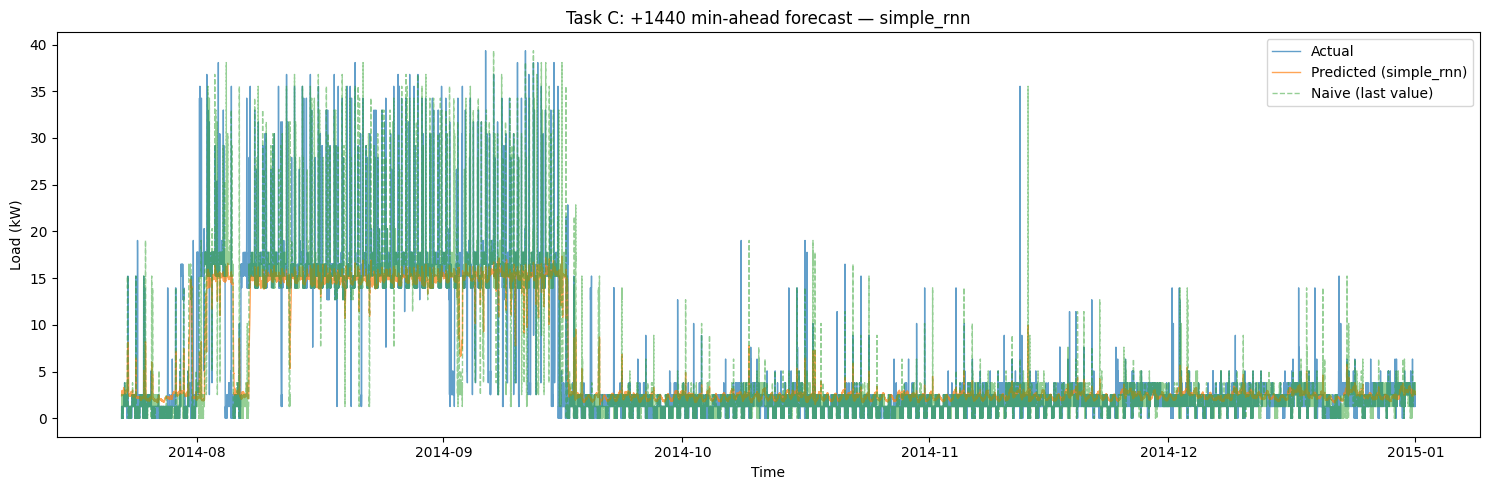

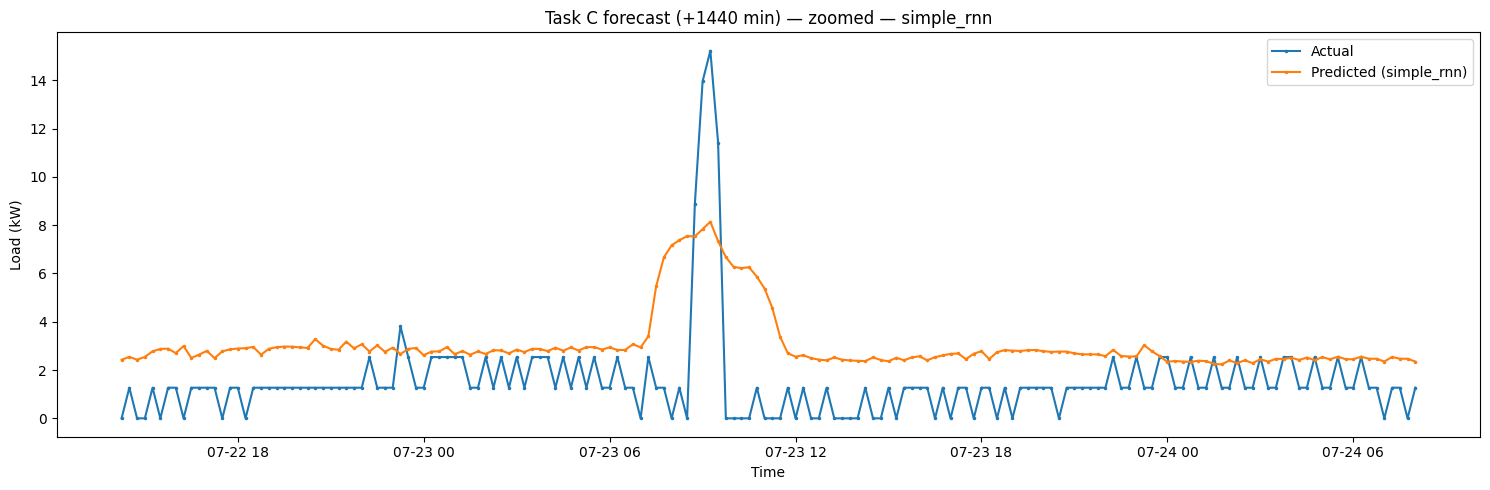

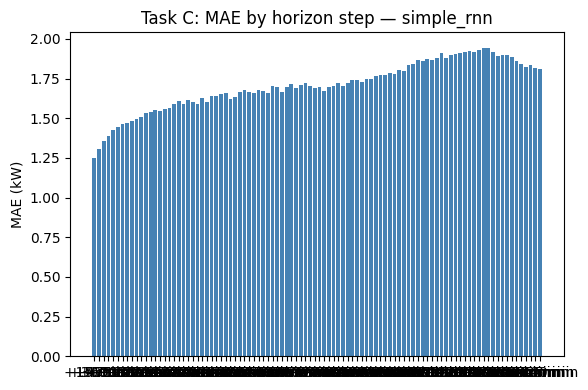

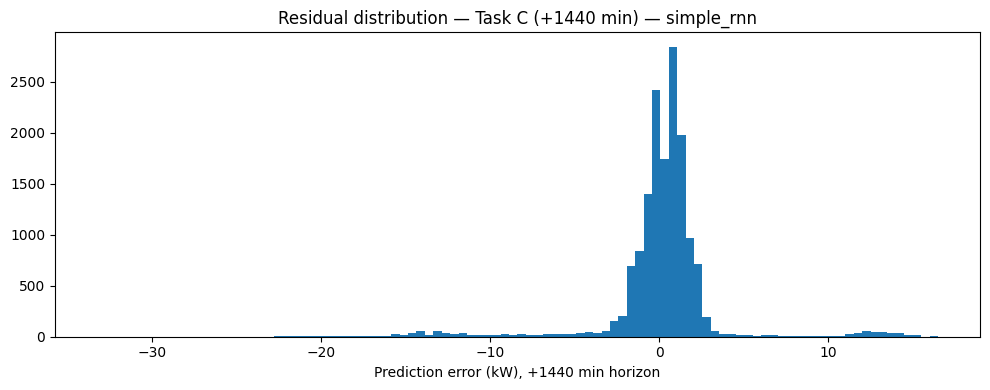


simple_rnn — mean absolute error by hour of day (+1440 min):
hour
9     3.029492
7     2.756790
10    2.441372
14    2.197301
11    2.176988
8     2.157049
18    2.030287
15    1.951306
6     1.753929
13    1.670388
12    1.651744
21    1.642920
19    1.625821
17    1.600762
2     1.549523
5     1.542433
1     1.527363
3     1.513939
0     1.490819
16    1.472182
4     1.471497
23    1.463624
22    1.448874
20    1.360700
Name: abs_error, dtype: float32


In [86]:
results_rnn, y_pred_rnn, y_true_rnn = evaluate_model_full(
    model_C, test_ds_C, load_scaler, feature_cols, test,
    model_name="simple_rnn", task_name="C"
)
visualize_forecast(y_true_rnn, y_pred_rnn, test,
                    model_name="simple_rnn", task_name="C",
                    test_ds=test_ds_C, load_scaler=load_scaler, feature_cols=feature_cols)

### **Stacked LSTM**

In [87]:
def build_stacked_lstm_model(input_len: int, n_features: int, output_len: int,
                               units_1: int = 64, units_2: int = 32, dropout: float = 0.2):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_len, n_features)),
        tf.keras.layers.LSTM(units_1, return_sequences=True),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.LSTM(units_2, return_sequences=False),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(output_len),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

In [88]:
model_C_lstm_stacked = build_stacked_lstm_model(96, n_features, output_len=96)
model_C_lstm_stacked.summary()
callbacks_C_lstm_stacked, log_dir_C_lstm_stacked = make_callbacks("task_C_lstm_stacked")


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 96, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 96)             │         1,632 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,264 (129.94 KB)

 Trainable params: 33,264 (129.94 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
history_C_lstm_stacked = model_C_lstm_stacked.fit(
    train_ds_C, validation_data=val_ds_C, epochs=1000,
    callbacks=callbacks_C_lstm_stacked, verbose=1,
)

Epoch 1/1000
   1145/Unknown 21s 16ms/step - loss: 0.7910 - mae: 0.6613

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.38891, saving model to /content/drive/MyDrive/logs/task_C_lstm_stacked/20260901-163137/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/logs/task_C_lstm_stacked/20260901-163137/best_model.keras
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - loss: 0.4771 - mae: 0.4732 - val_loss: 0.3889 - val_mae: 0.3633 - learning_rate: 0.0010
Epoch 2/1000
1147/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6175 - mae: 0.5087
Epoch 2: val_loss improved from 0.38891 to 0.38102, saving model to /content/drive/MyDrive/logs/task_C_lstm_stacked/20260901-163137/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/logs/task_C_lstm_stacked/20260901-163137/best_model.keras
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - loss: 0.3926 - mae: 0.3604 - val_loss: 0.3810 - val_mae: 0.3381 - learning_rate: 0.0010
Epoch 3/1000
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5912 - mae: 0.4908
Epoch 3: val_loss did not impr

In [90]:
results_lstm_stacked, y_pred_lstm_stacked, y_true_lstm_stacked = evaluate_model_full(
    model_C_lstm_stacked, test_ds_C, load_scaler, feature_cols, test,
    model_name="lstm_stacked", task_name="C"
)

244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
LSTM_STACKED — Task C
MAE:  2.0930 kW   (naive: 1.9818 kW)
RMSE: 3.6223 kW   (naive: 4.1755 kW)
MAPE (masked, |y|>0.1kW): 69.65%
MAE improvement vs naive:  -5.6%
RMSE improvement vs naive: 13.2%
  step 1 — MAE: 1.7893 kW
  step 2 — MAE: 1.8000 kW
  step 3 — MAE: 1.8014 kW
  step 4 — MAE: 1.8080 kW
  step 5 — MAE: 1.8143 kW
  step 6 — MAE: 1.7974 kW
  step 7 — MAE: 1.7948 kW
  step 8 — MAE: 1.8333 kW
  step 9 — MAE: 1.8462 kW
  step 10 — MAE: 1.8382 kW
  step 11 — MAE: 1.8018 kW
  step 12 — MAE: 1.8393 kW
  step 13 — MAE: 1.8351 kW
  step 14 — MAE: 1.8698 kW
  step 15 — MAE: 1.8586 kW
  step 16 — MAE: 1.9003 kW
  step 17 — MAE: 1.8305 kW
  step 18 — MAE: 1.8457 kW
  step 19 — MAE: 1.8172 kW
  step 20 — MAE: 1.8415 kW
  step 21 — MAE: 1.8848 kW
  step 22 — MAE: 1.8761 kW
  step 23 — MAE: 1.9059 kW
  step 24 — MAE: 1.8872 kW
  step 25 — MAE: 1.9071 kW
  step 26 — MAE: 1.9009 kW
  step 27 — MAE: 1.9123 kW
  step 28 — MAE: 1.8915 kW
  step 29 — MAE: 

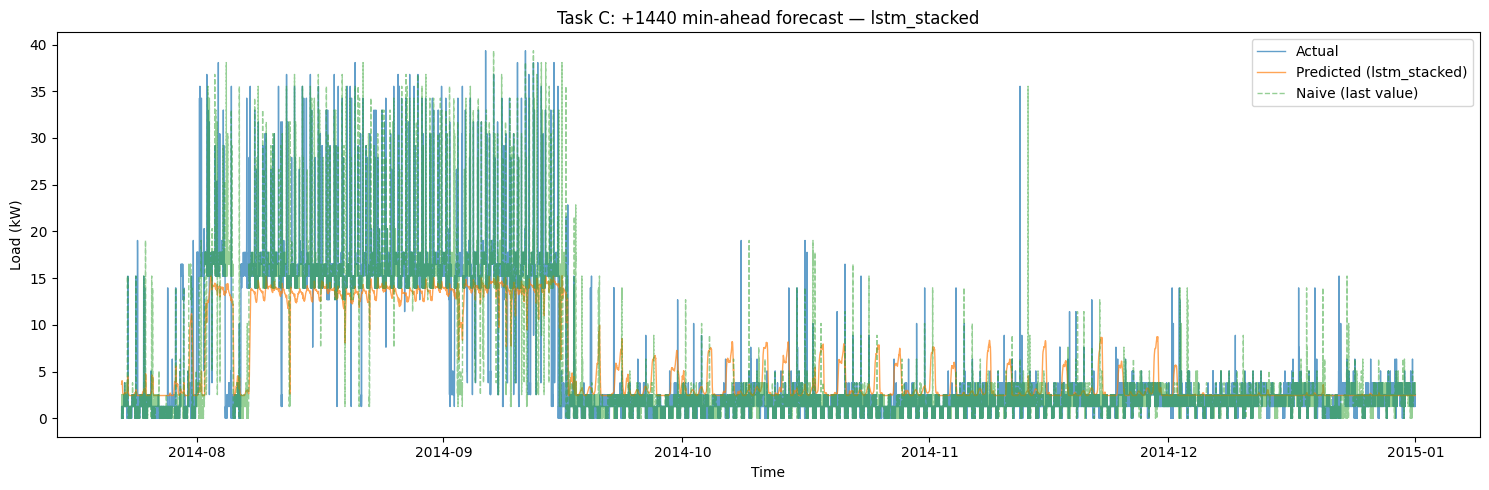

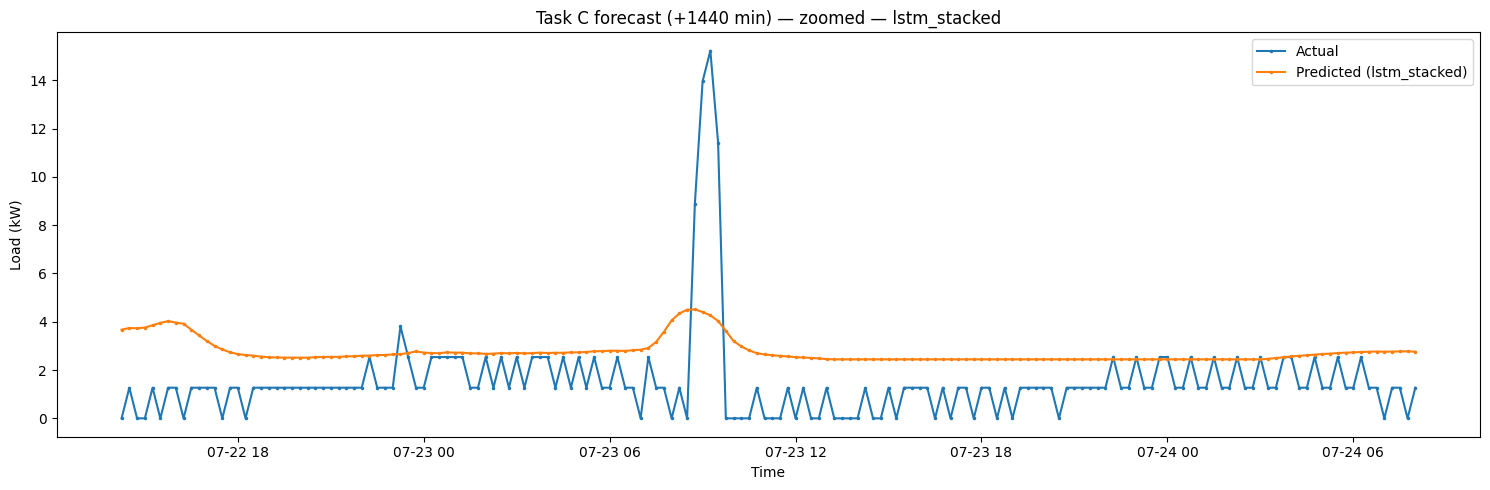

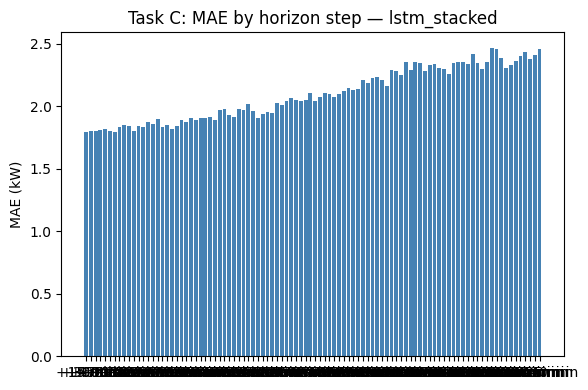

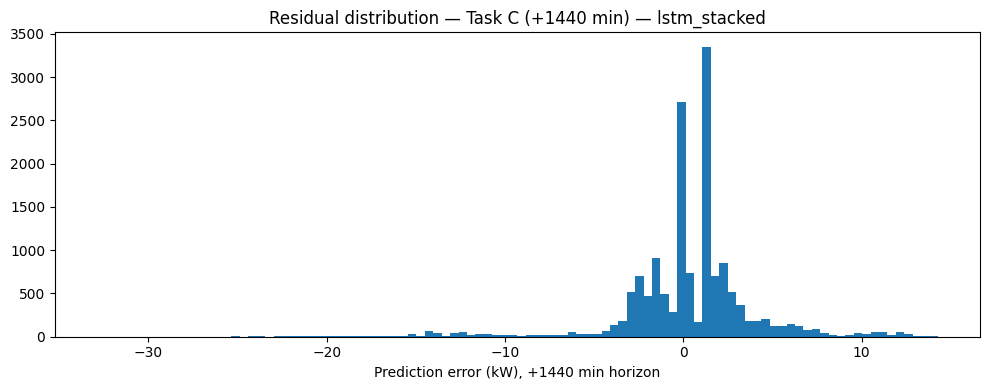


lstm_stacked — mean absolute error by hour of day (+1440 min):
hour
9     3.676371
7     3.550985
10    3.199192
14    3.050055
11    2.970119
8     2.824475
13    2.654099
12    2.617295
15    2.610086
6     2.543514
18    2.481878
5     2.257940
17    2.237139
16    2.234160
4     2.198264
3     2.152780
21    2.109268
2     2.088080
1     2.014287
22    1.973378
23    1.964926
0     1.935309
19    1.924895
20    1.663594
Name: abs_error, dtype: float32


In [91]:
visualize_forecast(y_true_lstm_stacked, y_pred_lstm_stacked, test,
                    model_name="lstm_stacked", task_name="C",
                    test_ds=test_ds_C, load_scaler=load_scaler, feature_cols=feature_cols)

### **GRU**

In [92]:
def build_gru_model(input_len: int, n_features: int, output_len: int, units: int = 32):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_len, n_features)),
        tf.keras.layers.GRU(units, return_sequences=False),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(output_len),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

In [93]:
model_C_gru = build_gru_model(96, n_features, output_len=96)
model_C_gru.summary()
callbacks_C_gru, log_dir_C_gru = make_callbacks("task_C_GRU")


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 32)             │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 96)             │         1,632 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,192 (24.19 KB)

 Trainable params: 6,192 (24.19 KB)

 Non-trainable params: 0 (0.00 B)

In [94]:
history_C_gru = model_C_gru.fit(
    train_ds_C, validation_data=val_ds_C, epochs=1000,
    callbacks=callbacks_C_gru, verbose=1,
)

Epoch 1/1000
   1146/Unknown 15s 12ms/step - loss: 0.7972 - mae: 0.5926

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.37344, saving model to /content/drive/MyDrive/logs/task_C_GRU/20260901-163701/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/logs/task_C_GRU/20260901-163701/best_model.keras
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 0.4435 - mae: 0.3871 - val_loss: 0.3734 - val_mae: 0.3308 - learning_rate: 0.0010
Epoch 2/1000
1147/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5962 - mae: 0.4985
Epoch 2: val_loss improved from 0.37344 to 0.36675, saving model to /content/drive/MyDrive/logs/task_C_GRU/20260901-163701/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/logs/task_C_GRU/20260901-163701/best_model.keras
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.3825 - mae: 0.3538 - val_loss: 0.3668 - val_mae: 0.3326 - learning_rate: 0.0010
Epoch 3/1000
1146/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5712 - mae: 0.4805
Epoch 3: val_loss improved from 0.36675 to 0.36193, saving model t

In [95]:
results_gru, y_pred_gru, y_true_gru = evaluate_model_full(
    model_C_gru, test_ds_C, load_scaler, feature_cols, test,
    model_name="gru", task_name="C"
)

244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
GRU — Task C
MAE:  1.8711 kW   (naive: 1.9818 kW)
RMSE: 3.4292 kW   (naive: 4.1755 kW)
MAPE (masked, |y|>0.1kW): 57.74%
MAE improvement vs naive:  5.6%
RMSE improvement vs naive: 17.9%
  step 1 — MAE: 1.2850 kW
  step 2 — MAE: 1.3550 kW
  step 3 — MAE: 1.4211 kW
  step 4 — MAE: 1.4220 kW
  step 5 — MAE: 1.4894 kW
  step 6 — MAE: 1.5536 kW
  step 7 — MAE: 1.5694 kW
  step 8 — MAE: 1.6256 kW
  step 9 — MAE: 1.5690 kW
  step 10 — MAE: 1.5986 kW
  step 11 — MAE: 1.6071 kW
  step 12 — MAE: 1.5394 kW
  step 13 — MAE: 1.5517 kW
  step 14 — MAE: 1.5900 kW
  step 15 — MAE: 1.5165 kW
  step 16 — MAE: 1.6033 kW
  step 17 — MAE: 1.6847 kW
  step 18 — MAE: 1.6910 kW
  step 19 — MAE: 1.6285 kW
  step 20 — MAE: 1.7653 kW
  step 21 — MAE: 1.6770 kW
  step 22 — MAE: 1.7386 kW
  step 23 — MAE: 1.7227 kW
  step 24 — MAE: 1.6726 kW
  step 25 — MAE: 1.6890 kW
  step 26 — MAE: 1.7417 kW
  step 27 — MAE: 1.7295 kW
  step 28 — MAE: 1.6690 kW
  step 29 — MAE: 1.6967 kW


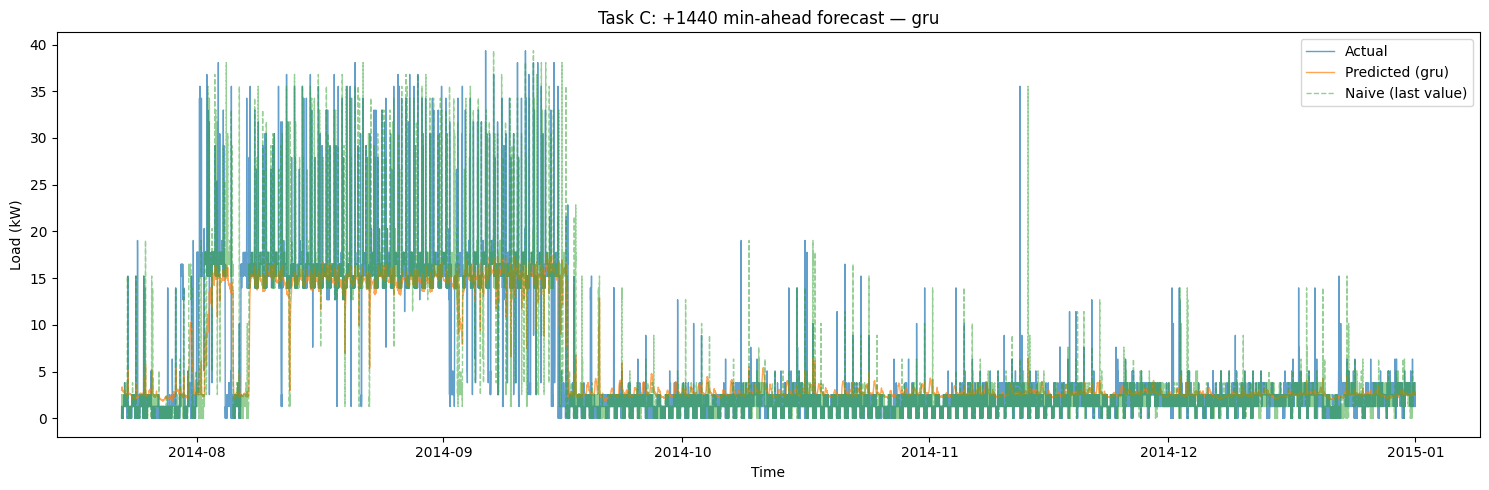

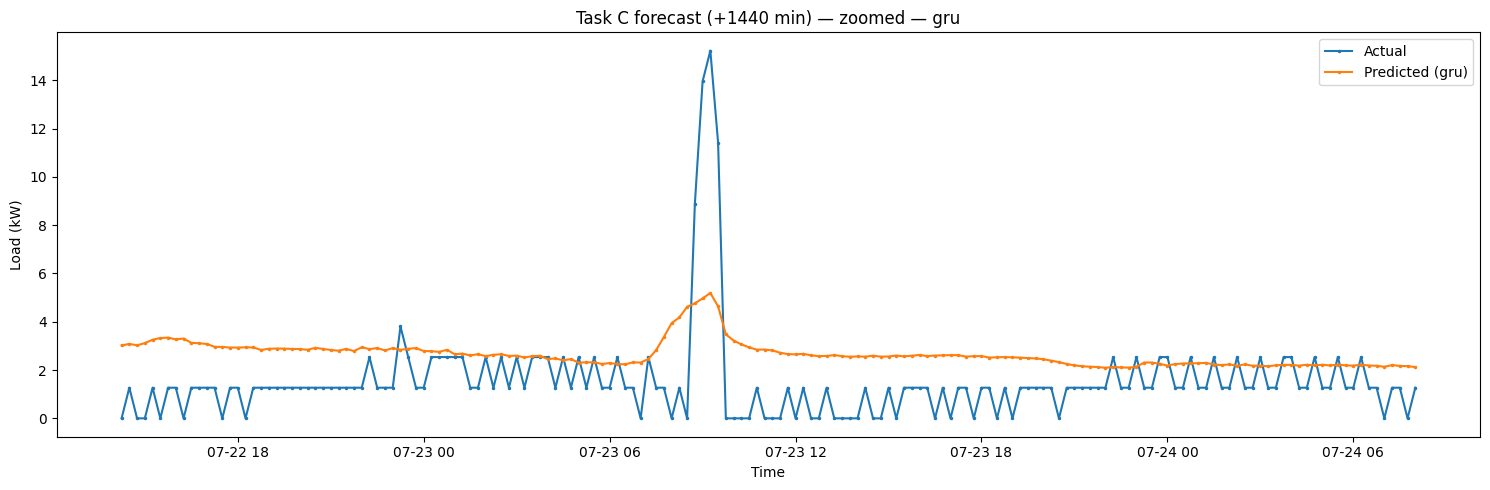

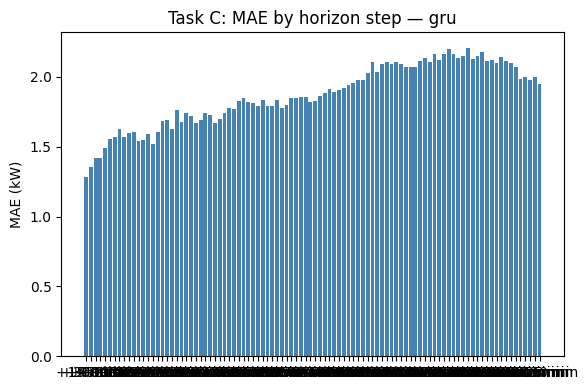

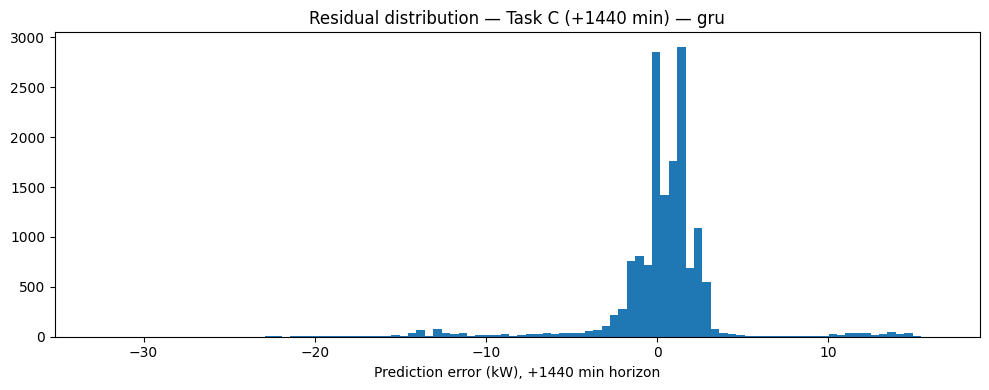


gru — mean absolute error by hour of day (+1440 min):
hour
9     3.109239
7     2.776128
10    2.542355
14    2.458342
11    2.349210
8     2.223830
18    2.123307
15    2.056095
13    1.997151
12    1.933049
17    1.819067
6     1.791919
2     1.791478
3     1.753056
1     1.693358
4     1.685609
5     1.673078
19    1.668707
21    1.665224
16    1.634934
23    1.626143
0     1.614249
22    1.536319
20    1.347818
Name: abs_error, dtype: float32


In [96]:
visualize_forecast(y_true_gru, y_pred_gru, test,
                    model_name="gru", task_name="C",
                    test_ds=test_ds_C, load_scaler=load_scaler, feature_cols=feature_cols)

## **Transformer**

In [97]:
class PositionalEncoding(tf.keras.layers.Layer):

  def __init__(self, seq_len, d_model, **kwargs):
    super().__init__(**kwargs)
    position = np.arange(seq_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    self.pe = tf.constant(pe, dtype=tf.float32)

  def call(self, x):
    return x + self.pe


def transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout=0.1):
  attn = tf.keras.layers.MultiHeadAttention(
      num_heads=num_heads, key_dim=d_model // num_heads
  )(x, x)
  attn = tf.keras.layers.Dropout(dropout)(attn)
  x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + attn)

  ff = tf.keras.layers.Dense(ff_dim, activation="relu")(x)
  ff = tf.keras.layers.Dense(d_model)(ff)
  ff = tf.keras.layers.Dropout(dropout)(ff)
  x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + ff)
  return x


def build_transformer_model(
    input_len: int,
    n_features: int,
    output_len: int,
    d_model: int = 32,
    num_heads: int = 4,
    ff_dim: int = 64,
    num_blocks: int = 2,
    dropout: float = 0.1,
):
  inputs = tf.keras.layers.Input(shape=(input_len, n_features))
  x = tf.keras.layers.Dense(d_model)(inputs)
  x = PositionalEncoding(input_len, d_model)(x)

  for _ in range(num_blocks):
    x = transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout)

  x = tf.keras.layers.GlobalAveragePooling1D()(x)
  x = tf.keras.layers.Dense(16, activation="relu")(x)
  outputs = tf.keras.layers.Dense(output_len)(x)

  model = tf.keras.Model(inputs, outputs)
  model.compile(optimizer="adam", loss="mse", metrics=["mae"])
  return model

In [98]:
model_C_transformer = build_transformer_model(input_len=96, n_features=n_features, output_len=96)
model_C_transformer.summary()
callbacks_C_trans, log_dir_C_trans = make_callbacks("task_C_transformer")


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 96, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 96, 32)    │        288 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 96, 32)    │          0 │ dense_19[0][0]    │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 96, 32)    │      4,224 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 96, 32)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 96, 32)    │          0 │ positional_encod… │
│                     │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 96, 32)    │         64 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 96, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 96, 32)    │      2,080 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 96, 32)    │          0 │ dense_21[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 96, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 96, 32)    │         64 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 96, 32)    │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 96, 32)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 96, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 96, 32)    │         64 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 96, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 96, 32)    │      2,080 │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 19,536 (76.31 KB)

 Trainable params: 19,536 (76.31 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
history_C_transformer = model_C_transformer.fit(
    train_ds_C, validation_data=val_ds_C, epochs=1000,
    callbacks=callbacks_C_trans, verbose=1,
)

Epoch 1/1000
   1148/Unknown 27s 13ms/step - loss: 0.7883 - mae: 0.5746

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.36642, saving model to /content/drive/MyDrive/logs/task_C_transformer/20260901-164059/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/logs/task_C_transformer/20260901-164059/best_model.keras
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - loss: 0.4385 - mae: 0.3759 - val_loss: 0.3664 - val_mae: 0.3290 - learning_rate: 0.0010
Epoch 2/1000
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6037 - mae: 0.5042
Epoch 2: val_loss did not improve from 0.36642
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.3821 - mae: 0.3526 - val_loss: 0.3709 - val_mae: 0.3189 - learning_rate: 0.0010
Epoch 3/1000
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5684 - mae: 0.4791
Epoch 3: val_loss did not improve from 0.36642
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.3648 - mae: 0.3407 - val_loss: 0.3782 - val_mae: 0.3474 - learning_rate: 0.0010
Epoch 4/1000
1144/1148 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5520 

In [100]:
results_trans, y_pred_trans, y_true_trans = evaluate_model_full(
    model=model_C_transformer, test_ds=test_ds_C,
    load_scaler=load_scaler, feature_cols=feature_cols, test_df=test,
    model_name="transformer", task_name="C",
)

244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
TRANSFORMER — Task C
MAE:  1.7487 kW   (naive: 1.9818 kW)
RMSE: 3.3825 kW   (naive: 4.1755 kW)
MAPE (masked, |y|>0.1kW): 50.04%
MAE improvement vs naive:  11.8%
RMSE improvement vs naive: 19.0%
  step 1 — MAE: 1.4209 kW
  step 2 — MAE: 1.4148 kW
  step 3 — MAE: 1.4750 kW
  step 4 — MAE: 1.4824 kW
  step 5 — MAE: 1.4598 kW
  step 6 — MAE: 1.5095 kW
  step 7 — MAE: 1.5262 kW
  step 8 — MAE: 1.5501 kW
  step 9 — MAE: 1.4951 kW
  step 10 — MAE: 1.6208 kW
  step 11 — MAE: 1.5450 kW
  step 12 — MAE: 1.5459 kW
  step 13 — MAE: 1.6347 kW
  step 14 — MAE: 1.6167 kW
  step 15 — MAE: 1.6114 kW
  step 16 — MAE: 1.6327 kW
  step 17 — MAE: 1.6564 kW
  step 18 — MAE: 1.5673 kW
  step 19 — MAE: 1.5539 kW
  step 20 — MAE: 1.7108 kW
  step 21 — MAE: 1.6390 kW
  step 22 — MAE: 1.6331 kW
  step 23 — MAE: 1.6620 kW
  step 24 — MAE: 1.6169 kW
  step 25 — MAE: 1.6142 kW
  step 26 — MAE: 1.6666 kW
  step 27 — MAE: 1.6598 kW
  step 28 — MAE: 1.7120 kW
  step 29 — MAE: 1

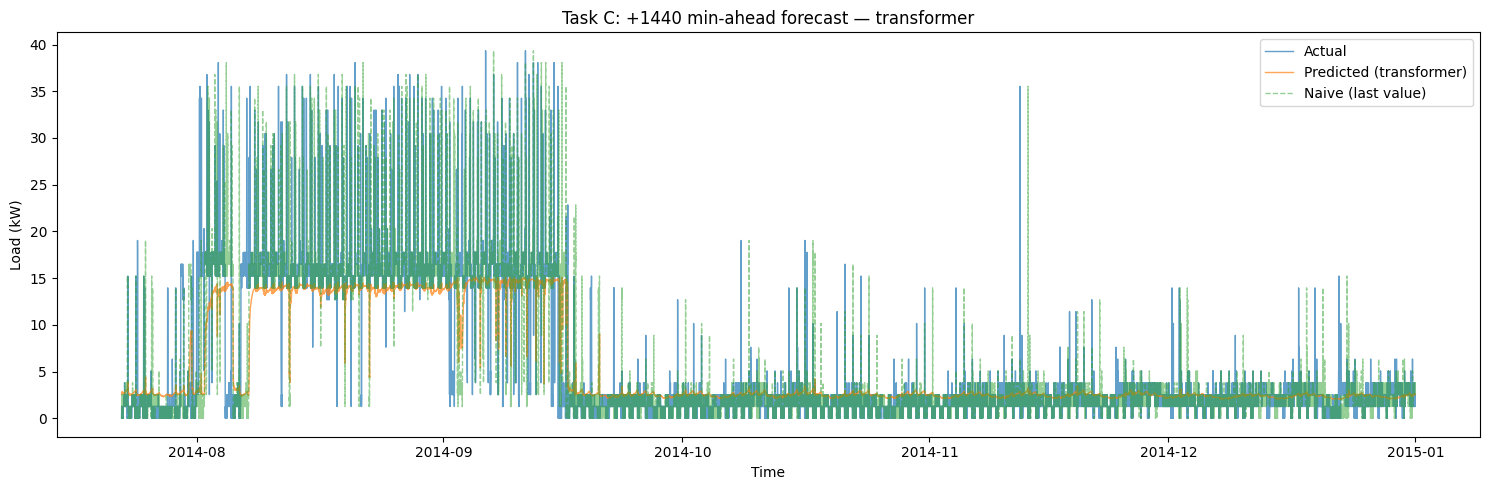

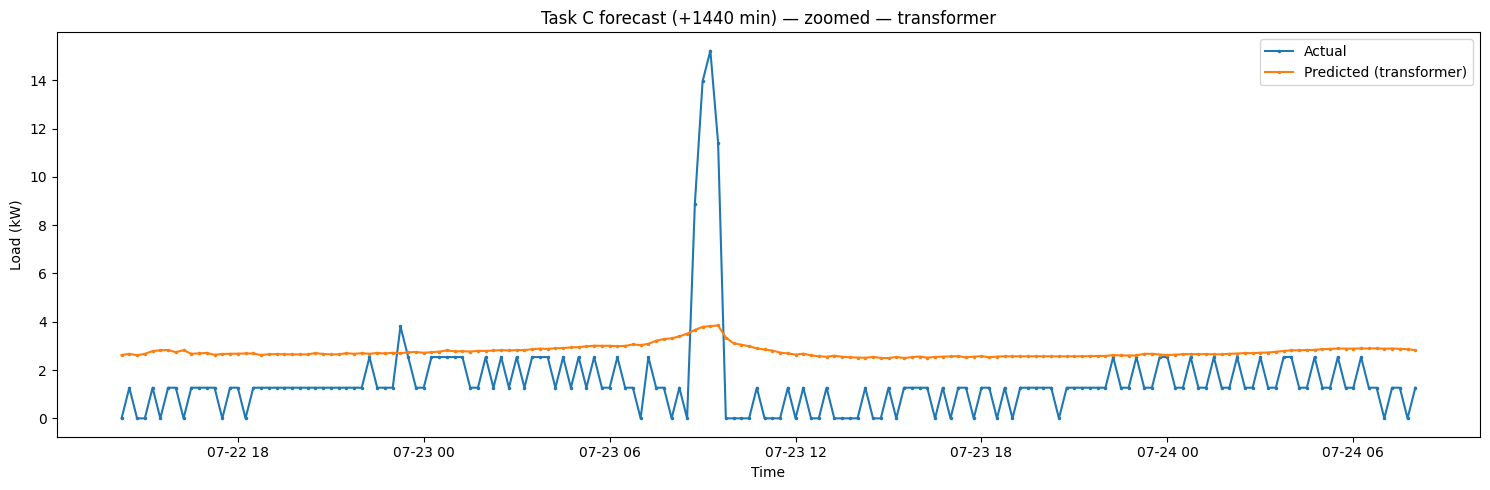

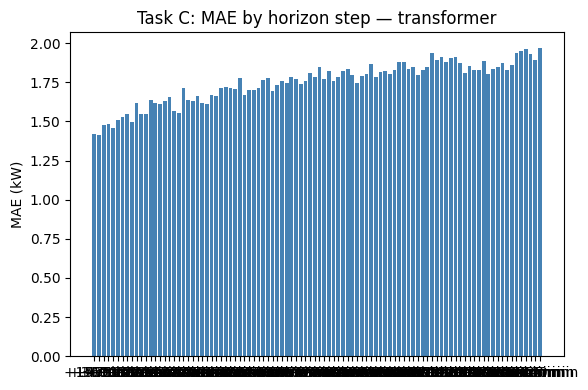

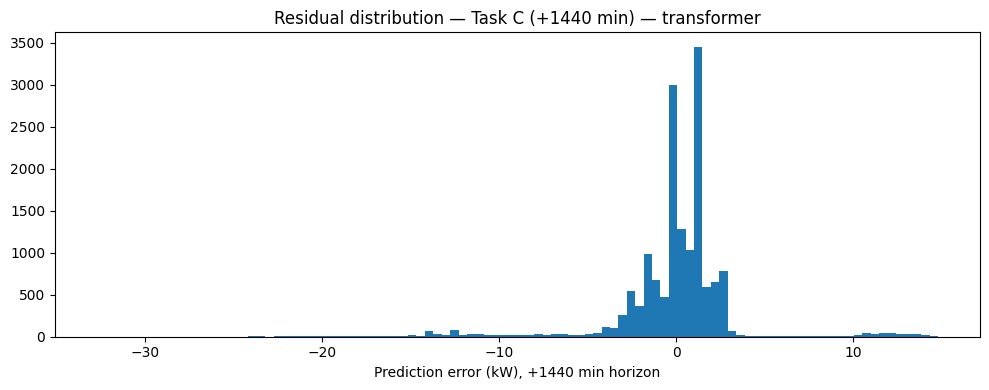


transformer — mean absolute error by hour of day (+1440 min):
hour
9     3.097282
7     2.912052
10    2.444346
14    2.406783
11    2.300314
8     2.244112
18    2.229039
15    2.104642
13    1.953695
21    1.886139
6     1.879816
12    1.860793
19    1.799913
17    1.790998
22    1.696981
23    1.685601
16    1.665305
2     1.662086
1     1.651605
0     1.636867
5     1.633544
3     1.624902
4     1.604122
20    1.530657
Name: abs_error, dtype: float32


In [101]:
visualize_forecast(y_true_trans, y_pred_trans, test,
                    model_name="transformer", task_name="C",
                    test_ds=test_ds_C, load_scaler=load_scaler, feature_cols=feature_cols)